# Gaming Toxicity Detection — Cross-Game Binary Experiment
**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward

**Research question:** Does toxicity detection generalise across games?

**Pipeline:**
1. Binarise both datasets: `label > 0 → 1` (toxic), `label == 0 → 0` (non-toxic)
2. Train on WoT → evaluate on WoT (in-game) and Dota (cross-game)
3. Train on Dota → evaluate on Dota (in-game) and WoT (cross-game)

## 0. Imports & Configuration

In [1]:
import warnings, time, joblib
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import f1_score, classification_report
from sklearn.base import clone

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 100})

In [2]:
CONFIG = {
    'seed': 7524,
    'data_dir': Path('../data/processed_data'),
    'models_dir': Path('../models'),
    'text_col': 'clean_message',
    'label_col': 'label',
    'cv_folds': 5,
    'scoring': 'f1_macro',
    'optuna_trials': 30,
    'n_top_features': 20,
    'tfidf': dict(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        norm='l2',
    ),
    'class_map': {0: 'Non-Toxic', 1: 'Toxic'},
}

seed = CONFIG['seed']
np.random.seed(seed)
class_names = ['Non-Toxic', 'Toxic']
cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=seed)
CONFIG['models_dir'].mkdir(exist_ok=True)

print('CONFIG loaded. Classes:', class_names)

CONFIG loaded. Classes: ['Non-Toxic', 'Toxic']


In [3]:
def start_study_optuna(objective, n_trials, seed, direction='maximize'):
    sampler = TPESampler(seed=seed)
    study   = optuna.create_study(direction=direction, sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    print(f'Best params: {study.best_params}')
    return study

# multi class score 
def score_multiclass(model, X_train, X_test, y_train, y_test):
    """Fit model on train, evaluate on test - returns classification_report + scores."""

    # fit the model
    model.fit(X_train, y_train)

    # predict 
    y_pred = model.predict(X_test)

    # classification report 
    print("Test classification report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))
    
OVERSAMPLERS = {
    'RandomOverSampler': RandomOverSampler(random_state=seed),
    'SMOTE':             SMOTE(random_state=seed),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=seed),
    'ADASYN':            ADASYN(random_state=seed),
}

## 1. Load & Binarise Both Datasets

In [4]:
d  = CONFIG['data_dir']
tc = CONFIG['text_col']
lc = CONFIG['label_col']

# --- WoT ---
wot_train = pd.read_parquet(d / 'wot_train_ml.parquet')
wot_test  = pd.read_parquet(d / 'wot_val_ml.parquet')

X_wot_train = wot_train[tc]
y_wot_train = (wot_train[lc].astype(int) > 0).astype(int)   # binary

X_wot_test  = wot_test[tc]
y_wot_test  = (wot_test[lc].astype(int) > 0).astype(int)

# --- Dota ---
dota_train = pd.read_parquet(d / 'dota_train_ml.parquet')
dota_test  = pd.read_parquet(d / 'dota_val_ml.parquet')

X_dota_train = dota_train[tc]
y_dota_train = (dota_train[lc].astype(int) > 0).astype(int)

X_dota_test  = dota_test[tc]
y_dota_test  = (dota_test[lc].astype(int) > 0).astype(int)

for name, y in [('WoT train', y_wot_train), ('WoT test', y_wot_test),
                ('Dota train', y_dota_train), ('Dota test', y_dota_test)]:
    toxic = y.sum()
    print(f'{name:<12}  total={len(y):>6}  toxic={toxic:>5} ({toxic/len(y)*100:.1f}%)  non-toxic={len(y)-toxic:>6} ({(len(y)-toxic)/len(y)*100:.1f}%)') 

WoT train     total= 33372  toxic= 6256 (18.7%)  non-toxic= 27116 (81.3%)
WoT test      total=  8343  toxic= 1564 (18.7%)  non-toxic=  6779 (81.3%)
Dota train    total= 24589  toxic= 6679 (27.2%)  non-toxic= 17910 (72.8%)
Dota test     total=  6148  toxic= 1670 (27.2%)  non-toxic=  4478 (72.8%)


---
## 2. World of Tanks Model

### 2.1 Oversampling Comparison

In [5]:
reference = LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=1)
wot_os_comparison = []

for os_name, sampler in OVERSAMPLERS.items():
    t0 = time.time()
    results = cross_validate(
        ImbPipeline([
            ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
            ('oversample', sampler),
            ('clf',        reference),
        ]),
        X_wot_train, y_wot_train, cv=cv,
        scoring=['f1_macro', 'f1_weighted', 'accuracy'],
        n_jobs=-1
    )
    wot_os_comparison.append({
        'Oversampler':    os_name,
        'CV Macro F1':    round(results['test_f1_macro'].mean(), 4),
        'CV Weighted F1': round(results['test_f1_weighted'].mean(), 4),
        'Std':            round(results['test_f1_macro'].std(), 4),
        'Time (s)':       round(time.time() - t0, 1),
    })
    print(f'{os_name:<20}  macro F1 = {results["test_f1_macro"].mean():.4f} +/- {results["test_f1_macro"].std():.4f}')

wot_os_df = pd.DataFrame(wot_os_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
wot_os_df

RandomOverSampler     macro F1 = 0.8282 +/- 0.0037
SMOTE                 macro F1 = 0.8249 +/- 0.0030
BorderlineSMOTE       macro F1 = 0.7411 +/- 0.0047
ADASYN                macro F1 = 0.7355 +/- 0.0041


,Oversampler,CV Macro F1,CV Weighted F1,Std,Time (s)
0,RandomOverSampler,0.8282,0.8933,0.0037,3.0
1,SMOTE,0.8249,0.8919,0.0030,2.8
2,BorderlineSMOTE,0.7411,0.8229,0.0047,5.0
3,ADASYN,0.7355,0.8168,0.0041,6.0


### 2.2 Model Selection

In [6]:
wot_best_os = RandomOverSampler(random_state=seed)
wot_models_comparison = []

# --- Logistic Regression ---
print('--- Logistic Regression ---')
wot_lr_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', wot_best_os),
    ('clf',        LogisticRegressionCV(Cs=30, cv=cv, scoring='f1_macro',
                                        max_iter=1000, random_state=seed, n_jobs=-1)),
])
t0 = time.time()
wot_lr_results = cross_validate(wot_lr_pipe, X_wot_train, y_wot_train, cv=cv,
                                 scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
wot_models_comparison.append({
    'Model':          'Logistic Regression',
    'CV Macro F1':    round(wot_lr_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(wot_lr_results['test_f1_weighted'].mean(), 4),
    'Std':            round(wot_lr_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(wot_models_comparison)

--- Logistic Regression ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8199,0.8879,0.0056,2.7


In [1]:
# apply on test data
score_multiclass(wot_lr_pipe, 
                 X_wot_train, 
                 X_wot_test, 
                 y_wot_train, 
                 y_wot_test)

NameError: name 'score_multiclass' is not defined

In [8]:
# --- Naive Bayes (Optuna) ---
print('--- Naive Bayes (Optuna TPE) ---')
wot_nb_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', wot_best_os),
    ('clf',        MultinomialNB()),
])

def wot_objective_nb(trial):
    params = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}
    pipe   = clone(wot_nb_pipe)
    pipe.set_params(**params)
    return cross_val_score(pipe, X_wot_train, y_wot_train, cv=cv,
                           scoring=CONFIG['scoring'], n_jobs=1).mean()

wot_study_nb = start_study_optuna(wot_objective_nb, n_trials=CONFIG['optuna_trials'], seed=seed)
wot_nb_pipe.set_params(**wot_study_nb.best_params)

t0 = time.time()
wot_nb_results = cross_validate(wot_nb_pipe, X_wot_train, y_wot_train, cv=cv,
                                 scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
wot_models_comparison.append({
    'Model':          'Naive Bayes',
    'CV Macro F1':    round(wot_nb_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(wot_nb_results['test_f1_weighted'].mean(), 4),
    'Std':            round(wot_nb_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(wot_models_comparison)

--- Naive Bayes (Optuna TPE) ---
Best params: {'clf__alpha': 1.599987931495056}


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8199,0.8879,0.0056,2.7
1,Naive Bayes,0.7794,0.8545,0.0006,0.2


In [9]:
# apply on test data
score_multiclass(wot_nb_pipe, 
                 X_wot_train, 
                 X_wot_test, 
                 y_wot_train, 
                 y_wot_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      6779
           1       0.55      0.80      0.65      1564

    accuracy                           0.84      8343
   macro avg       0.75      0.82      0.77      8343
weighted avg       0.87      0.84      0.85      8343



In [10]:
# --- LinearSVC ---
print('--- LinearSVC ---')
wot_svc_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', wot_best_os),
    ('clf',        LinearSVC(C=1.0, max_iter=2000, tol=1e-3, random_state=seed)),
])
t0 = time.time()
wot_svc_results = cross_validate(wot_svc_pipe, X_wot_train, y_wot_train, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
wot_models_comparison.append({
    'Model':          'LinearSVC',
    'CV Macro F1':    round(wot_svc_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(wot_svc_results['test_f1_weighted'].mean(), 4),
    'Std':            round(wot_svc_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(wot_models_comparison)

--- LinearSVC ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8199,0.8879,0.0056,2.7
1,Naive Bayes,0.7794,0.8545,0.0006,0.2
2,LinearSVC,0.8162,0.8856,0.0036,0.4


In [11]:
# apply on test data
score_multiclass(wot_svc_pipe, 
                 X_wot_train, 
                 X_wot_test, 
                 y_wot_train, 
                 y_wot_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      6779
           1       0.66      0.74      0.70      1564

    accuracy                           0.88      8343
   macro avg       0.80      0.83      0.81      8343
weighted avg       0.89      0.88      0.88      8343



### 2.3 Select Best & Evaluate

In [12]:
WOT_MODELS = {
    'Logistic Regression': wot_lr_pipe,
    'Naive Bayes':         wot_nb_pipe,
    'LinearSVC':           wot_svc_pipe,
}
wot_compare_df       = pd.DataFrame(wot_models_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
wot_best_model_name  = wot_compare_df.iloc[0]['Model']
wot_best_pipe        = WOT_MODELS[wot_best_model_name]

print(wot_compare_df)
print(f'\nBest WoT model: {wot_best_model_name}')

                 Model  CV Macro F1  CV Weighted F1     Std  Time (s)
0  Logistic Regression       0.8199          0.8879  0.0056       2.7
1            LinearSVC       0.8162          0.8856  0.0036       0.4
2          Naive Bayes       0.7794          0.8545  0.0006       0.2

Best WoT model: Logistic Regression


### 2.4 Cross-Game: WoT model → Dota test

In [13]:
print('=== WoT model → Dota test (cross-game) ===')
y_wot_pred = wot_best_pipe.predict(X_wot_test)
y_wot_on_dota = wot_best_pipe.predict(X_dota_test)
print(classification_report(y_dota_test, y_wot_on_dota, target_names=class_names, zero_division=0))

wot_cross_macro = f1_score(y_dota_test, y_wot_on_dota, average='macro')
wot_ingame_macro = f1_score(y_wot_test, y_wot_pred, average='macro')
print(f'In-game macro F1:   {wot_ingame_macro:.4f}')
print(f'Cross-game macro F1: {wot_cross_macro:.4f}')
print(f'Generalisation drop: {wot_ingame_macro - wot_cross_macro:.4f}')

=== WoT model → Dota test (cross-game) ===
              precision    recall  f1-score   support

   Non-Toxic       0.82      0.88      0.85      4478
       Toxic       0.60      0.49      0.54      1670

    accuracy                           0.77      6148
   macro avg       0.71      0.68      0.70      6148
weighted avg       0.76      0.77      0.77      6148

In-game macro F1:   0.8077
Cross-game macro F1: 0.6953
Generalisation drop: 0.1124


### 2.5 Save WoT Model

In [14]:
wot_path = CONFIG['models_dir'] / f'binary_wot_{wot_best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(wot_best_pipe, wot_path)
print(f'Saved: {wot_path}')

Saved: ..\models\binary_wot_logistic_regression.joblib


---
## 3. Dota 2 Model

### 3.1 Oversampling Comparison

In [15]:
dota_os_comparison = []

for os_name, sampler in OVERSAMPLERS.items():
    t0 = time.time()
    results = cross_validate(
        ImbPipeline([
            ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
            ('oversample', sampler),
            ('clf',        LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=1)),
        ]),
        X_dota_train, y_dota_train, cv=cv,
        scoring=['f1_macro', 'f1_weighted', 'accuracy'],
        n_jobs=-1
    )
    dota_os_comparison.append({
        'Oversampler':    os_name,
        'CV Macro F1':    round(results['test_f1_macro'].mean(), 4),
        'CV Weighted F1': round(results['test_f1_weighted'].mean(), 4),
        'Std':            round(results['test_f1_macro'].std(), 4),
        'Time (s)':       round(time.time() - t0, 1),
    })
    print(f'{os_name:<20}  macro F1 = {results["test_f1_macro"].mean():.4f} +/- {results["test_f1_macro"].std():.4f}')

dota_os_df = pd.DataFrame(dota_os_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
dota_os_df

RandomOverSampler     macro F1 = 0.8819 +/- 0.0061
SMOTE                 macro F1 = 0.8766 +/- 0.0067
BorderlineSMOTE       macro F1 = 0.8713 +/- 0.0080
ADASYN                macro F1 = 0.8668 +/- 0.0057


,Oversampler,CV Macro F1,CV Weighted F1,Std,Time (s)
0,RandomOverSampler,0.8819,0.9072,0.0061,0.2
1,SMOTE,0.8766,0.9032,0.0067,0.7
2,BorderlineSMOTE,0.8713,0.8984,0.0080,2.3
3,ADASYN,0.8668,0.8943,0.0057,2.5


### 3.2 Model Selection

In [16]:
dota_best_os          = RandomOverSampler(random_state=seed)
dota_models_comparison = []

# --- Logistic Regression ---
print('--- Logistic Regression ---')
dota_lr_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        LogisticRegressionCV(Cs=30, cv=cv, scoring='f1_macro',
                                        max_iter=1000, random_state=seed, n_jobs=-1)),
])
t0 = time.time()
dota_lr_results = cross_validate(dota_lr_pipe, X_dota_train, y_dota_train, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'Logistic Regression',
    'CV Macro F1':    round(dota_lr_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_lr_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_lr_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- Logistic Regression ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.868,0.8954,0.0051,1.4


In [17]:
# apply on test data
score_multiclass(dota_lr_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4478
           1       0.81      0.82      0.82      1670

    accuracy                           0.90      6148
   macro avg       0.87      0.88      0.88      6148
weighted avg       0.90      0.90      0.90      6148



In [18]:
# --- Naive Bayes (Optuna) ---
print('--- Naive Bayes (Optuna TPE) ---')
dota_nb_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        MultinomialNB()),
])

def dota_objective_nb(trial):
    params = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}
    pipe   = clone(dota_nb_pipe)
    pipe.set_params(**params)
    return cross_val_score(pipe, X_dota_train, y_dota_train, cv=cv,
                           scoring=CONFIG['scoring'], n_jobs=1).mean()

dota_study_nb = start_study_optuna(dota_objective_nb, n_trials=CONFIG['optuna_trials'], seed=seed)
dota_nb_pipe.set_params(**dota_study_nb.best_params)

t0 = time.time()
dota_nb_results = cross_validate(dota_nb_pipe, X_dota_train, y_dota_train, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'Naive Bayes',
    'CV Macro F1':    round(dota_nb_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_nb_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_nb_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- Naive Bayes (Optuna TPE) ---
Best params: {'clf__alpha': 1.84475513983506}


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8680,0.8954,0.0051,1.4
1,Naive Bayes,0.8259,0.8586,0.0056,0.2


In [19]:
# apply on test data
score_multiclass(dota_nb_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.93      0.86      0.90      4478
           1       0.70      0.83      0.76      1670

    accuracy                           0.86      6148
   macro avg       0.82      0.85      0.83      6148
weighted avg       0.87      0.86      0.86      6148



In [20]:
# --- LinearSVC ---
print('--- LinearSVC ---')
dota_svc_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', dota_best_os),
    ('clf',        LinearSVC(C=1.0, max_iter=2000, tol=1e-3, random_state=seed)),
])
t0 = time.time()
dota_svc_results = cross_validate(dota_svc_pipe, X_dota_train, y_dota_train, cv=cv,
                                   scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
dota_models_comparison.append({
    'Model':          'LinearSVC',
    'CV Macro F1':    round(dota_svc_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(dota_svc_results['test_f1_weighted'].mean(), 4),
    'Std':            round(dota_svc_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})
pd.DataFrame(dota_models_comparison)

--- LinearSVC ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8680,0.8954,0.0051,1.4
1,Naive Bayes,0.8259,0.8586,0.0056,0.2
2,LinearSVC,0.8703,0.8973,0.0046,0.2


In [21]:
# apply on test data
score_multiclass(dota_svc_pipe, 
                 X_dota_train, 
                 X_dota_test, 
                 y_dota_train, 
                 y_dota_test)

Test classification report:

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      4478
           1       0.82      0.83      0.82      1670

    accuracy                           0.90      6148
   macro avg       0.88      0.88      0.88      6148
weighted avg       0.90      0.90      0.90      6148



### 3.3 Select Best & Evaluate

In [22]:
DOTA_MODELS = {
    'Logistic Regression': dota_lr_pipe,
    'Naive Bayes':         dota_nb_pipe,
    'LinearSVC':           dota_svc_pipe,
}
dota_compare_df      = pd.DataFrame(dota_models_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
dota_best_model_name = dota_compare_df.iloc[0]['Model']
dota_best_pipe       = DOTA_MODELS[dota_best_model_name]

print(dota_compare_df)
print(f'\nBest Dota model: {dota_best_model_name}')

                 Model  CV Macro F1  CV Weighted F1     Std  Time (s)
0            LinearSVC       0.8703          0.8973  0.0046       0.2
1  Logistic Regression       0.8680          0.8954  0.0051       1.4
2          Naive Bayes       0.8259          0.8586  0.0056       0.2

Best Dota model: LinearSVC


### 3.4 Cross-Game: Dota model → WoT test

In [23]:
print('=== Dota model → WoT test (cross-game) ===')
y_dota_pred = dota_best_pipe.predict(X_dota_test)
y_dota_on_wot = dota_best_pipe.predict(X_wot_test)
print(classification_report(y_wot_test, y_dota_on_wot, target_names=class_names, zero_division=0))

dota_cross_macro  = f1_score(y_wot_test, y_dota_on_wot, average='macro')
dota_ingame_macro = f1_score(y_dota_test, y_dota_pred,  average='macro')
print(f'In-game macro F1:    {dota_ingame_macro:.4f}')
print(f'Cross-game macro F1: {dota_cross_macro:.4f}')
print(f'Generalisation drop: {dota_ingame_macro - dota_cross_macro:.4f}')

=== Dota model → WoT test (cross-game) ===
              precision    recall  f1-score   support

   Non-Toxic       0.89      0.92      0.91      6779
       Toxic       0.60      0.52      0.56      1564

    accuracy                           0.84      8343
   macro avg       0.75      0.72      0.73      8343
weighted avg       0.84      0.84      0.84      8343

In-game macro F1:    0.8790
Cross-game macro F1: 0.7323
Generalisation drop: 0.1467


### 3.5 Save Dota Model

In [24]:
dota_path = CONFIG['models_dir'] / f'binary_dota_{dota_best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(dota_best_pipe, dota_path)
print(f'Saved: {dota_path}')

Saved: ..\models\binary_dota_linearsvc.joblib


---
## 4. Cross-Game Summary

Train              Test  Macro F1
  WoT     WoT (in-game)    0.8077
  WoT Dota (cross-game)    0.6953
 Dota    Dota (in-game)    0.8790
 Dota  WoT (cross-game)    0.7323


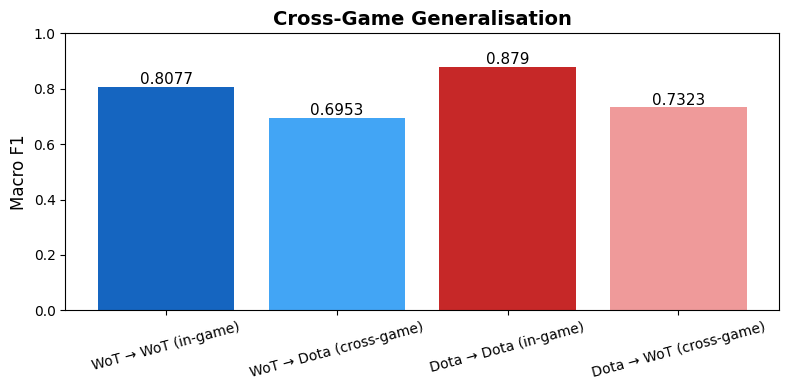

In [25]:
summary = pd.DataFrame([
    {'Train': 'WoT',  'Test': 'WoT (in-game)',   'Macro F1': round(f1_score(y_wot_test,  y_wot_pred,    average='macro'), 4)},
    {'Train': 'WoT',  'Test': 'Dota (cross-game)', 'Macro F1': round(f1_score(y_dota_test, y_wot_on_dota, average='macro'), 4)},
    {'Train': 'Dota', 'Test': 'Dota (in-game)',  'Macro F1': round(f1_score(y_dota_test, y_dota_pred,   average='macro'), 4)},
    {'Train': 'Dota', 'Test': 'WoT (cross-game)',  'Macro F1': round(f1_score(y_wot_test,  y_dota_on_wot, average='macro'), 4)},
])

print(summary.to_string(index=False))

# bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1565C0', '#42A5F5', '#C62828', '#EF9A9A']
ax.bar(summary['Train'] + ' → ' + summary['Test'], summary['Macro F1'], color=colors)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Cross-Game Generalisation', fontweight='bold', fontsize=14)
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(summary['Macro F1']):
    ax.text(i, v + 0.01, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Combined Training (WoT + Dota)

Pool both training sets into one, train a single model, evaluate on each game's out-of-sample test set separately.

**Question:** Does training on both games produce a more general toxicity detector than either alone?

### 5.1 Pool Datasets

In [26]:
X_combined = pd.concat([X_wot_train, X_dota_train], ignore_index=True)
y_combined = pd.concat([y_wot_train, y_dota_train], ignore_index=True)

print(f'Combined train: {len(X_combined):,} samples')
toxic = y_combined.sum()
print(f'Toxic: {toxic:,} ({toxic/len(y_combined)*100:.1f}%)  Non-toxic: {len(y_combined)-toxic:,} ({(len(y_combined)-toxic)/len(y_combined)*100:.1f}%)')

Combined train: 57,961 samples
Toxic: 12,935 (22.3%)  Non-toxic: 45,026 (77.7%)


### 5.2 Model Selection

In [27]:
# RandomOverSampler won both per-game comparisons — use it directly
comb_os = RandomOverSampler(random_state=seed)
comb_models_comparison = []

# --- Logistic Regression ---
print('--- Logistic Regression ---')
comb_lr_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', comb_os),
    ('clf',        LogisticRegressionCV(Cs=30, cv=cv, scoring='f1_macro',
                                        max_iter=1000, random_state=seed, n_jobs=-1)),
])
t0 = time.time()
comb_lr_results = cross_validate(comb_lr_pipe, X_combined, y_combined, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
comb_models_comparison.append({
    'Model':          'Logistic Regression',
    'CV Macro F1':    round(comb_lr_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(comb_lr_results['test_f1_weighted'].mean(), 4),
    'Std':            round(comb_lr_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})

# --- Naive Bayes (Optuna) ---
print('--- Naive Bayes (Optuna TPE) ---')
comb_nb_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', comb_os),
    ('clf',        MultinomialNB()),
])

def comb_objective_nb(trial):
    params = {'clf__alpha': trial.suggest_float('clf__alpha', 0.001, 2.0, log=True)}
    pipe   = clone(comb_nb_pipe)
    pipe.set_params(**params)
    return cross_val_score(pipe, X_combined, y_combined, cv=cv,
                           scoring=CONFIG['scoring'], n_jobs=1).mean()

comb_study_nb = start_study_optuna(comb_objective_nb, n_trials=CONFIG['optuna_trials'], seed=seed)
comb_nb_pipe.set_params(**comb_study_nb.best_params)
t0 = time.time()
comb_nb_results = cross_validate(comb_nb_pipe, X_combined, y_combined, cv=cv,
                                  scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
comb_models_comparison.append({
    'Model':          'Naive Bayes',
    'CV Macro F1':    round(comb_nb_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(comb_nb_results['test_f1_weighted'].mean(), 4),
    'Std':            round(comb_nb_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})

# --- LinearSVC ---
print('--- LinearSVC ---')
comb_svc_pipe = ImbPipeline([
    ('tfidf',      TfidfVectorizer(**CONFIG['tfidf'])),
    ('oversample', comb_os),
    ('clf',        LinearSVC(C=1.0, max_iter=2000, tol=1e-3, random_state=seed)),
])
t0 = time.time()
comb_svc_results = cross_validate(comb_svc_pipe, X_combined, y_combined, cv=cv,
                                   scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
comb_models_comparison.append({
    'Model':          'LinearSVC',
    'CV Macro F1':    round(comb_svc_results['test_f1_macro'].mean(), 4),
    'CV Weighted F1': round(comb_svc_results['test_f1_weighted'].mean(), 4),
    'Std':            round(comb_svc_results['test_f1_macro'].std(), 4),
    'Time (s)':       round(time.time() - t0, 1),
})

pd.DataFrame(comb_models_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)

--- Logistic Regression ---
--- Naive Bayes (Optuna TPE) ---
Best params: {'clf__alpha': 1.9462843636374072}
--- LinearSVC ---


,Model,CV Macro F1,CV Weighted F1,Std,Time (s)
0,Logistic Regression,0.8338,0.8829,0.0030,3.6
1,LinearSVC,0.8287,0.8792,0.0031,0.8
2,Naive Bayes,0.7897,0.8452,0.0016,0.4


### 5.3 Evaluate on WoT & Dota Test Sets

In [28]:
COMB_MODELS = {
    'Logistic Regression': comb_lr_pipe,
    'Naive Bayes':         comb_nb_pipe,
    'LinearSVC':           comb_svc_pipe,
}
comb_compare_df      = pd.DataFrame(comb_models_comparison).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
comb_best_model_name = comb_compare_df.iloc[0]['Model']
comb_best_pipe       = COMB_MODELS[comb_best_model_name]
print(f'Best combined model: {comb_best_model_name}\n')

# fit on full combined set
comb_best_pipe.fit(X_combined, y_combined)

# --- WoT test ---
y_comb_on_wot = comb_best_pipe.predict(X_wot_test)
print('=== Combined model → WoT test ===')
print(classification_report(y_wot_test, y_comb_on_wot, target_names=class_names, zero_division=0))

# --- Dota test ---
y_comb_on_dota = comb_best_pipe.predict(X_dota_test)
print('=== Combined model → Dota test ===')
print(classification_report(y_dota_test, y_comb_on_dota, target_names=class_names, zero_division=0))

Best combined model: Logistic Regression

=== Combined model → WoT test ===
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.92      0.93      6779
       Toxic       0.67      0.73      0.70      1564

    accuracy                           0.88      8343
   macro avg       0.80      0.82      0.81      8343
weighted avg       0.89      0.88      0.88      8343

=== Combined model → Dota test ===
              precision    recall  f1-score   support

   Non-Toxic       0.93      0.90      0.92      4478
       Toxic       0.76      0.82      0.79      1670

    accuracy                           0.88      6148
   macro avg       0.84      0.86      0.85      6148
weighted avg       0.88      0.88      0.88      6148



### 5.4 Save Combined Model

In [29]:
comb_path = CONFIG['models_dir'] / f'binary_combined_{comb_best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(comb_best_pipe, comb_path)
print(f'Saved: {comb_path}')

Saved: ..\models\binary_combined_logistic_regression.joblib


---
## 6. Full Summary

   Train Test       Type  Macro F1
     WoT  WoT    in-game    0.8077
     WoT Dota cross-game    0.6953
    Dota Dota    in-game    0.8790
    Dota  WoT cross-game    0.7323
WoT+Dota  WoT   combined    0.8132
WoT+Dota Dota   combined    0.8526


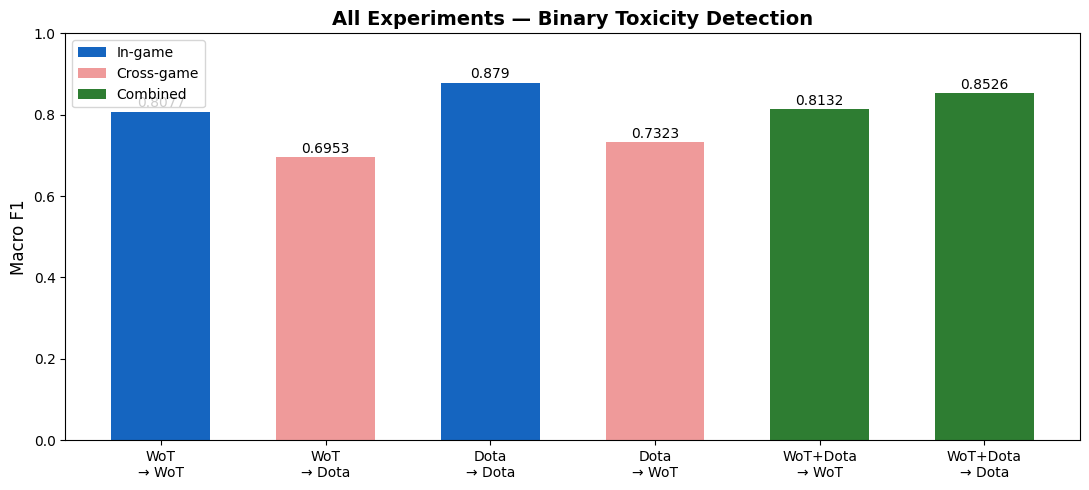

In [30]:
full_summary = pd.DataFrame([
    {'Train':     'WoT',      'Test': 'WoT',  'Type': 'in-game',    'Macro F1': round(f1_score(y_wot_test,  y_wot_pred,    average='macro'), 4)},
    {'Train':     'WoT',      'Test': 'Dota', 'Type': 'cross-game', 'Macro F1': round(f1_score(y_dota_test, y_wot_on_dota, average='macro'), 4)},
    {'Train':     'Dota',     'Test': 'Dota', 'Type': 'in-game',    'Macro F1': round(f1_score(y_dota_test, y_dota_pred,   average='macro'), 4)},
    {'Train':     'Dota',     'Test': 'WoT',  'Type': 'cross-game', 'Macro F1': round(f1_score(y_wot_test,  y_dota_on_wot, average='macro'), 4)},
    {'Train': 'WoT+Dota',     'Test': 'WoT',  'Type': 'combined',   'Macro F1': round(f1_score(y_wot_test,  y_comb_on_wot, average='macro'), 4)},
    {'Train': 'WoT+Dota',     'Test': 'Dota', 'Type': 'combined',   'Macro F1': round(f1_score(y_dota_test, y_comb_on_dota,average='macro'), 4)},
])

print(full_summary.to_string(index=False))

# grouped bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(full_summary))
colors = {'in-game': '#1565C0', 'cross-game': '#EF9A9A', 'combined': '#2E7D32'}
bars   = ax.bar(x, full_summary['Macro F1'],
                color=[colors[t] for t in full_summary['Type']], width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(
    full_summary['Train'] + '\n→ ' + full_summary['Test'],
    fontsize=10
)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('All Experiments — Binary Toxicity Detection', fontweight='bold', fontsize=14)
ax.set_ylim(0, 1)

for bar, v in zip(bars, full_summary['Macro F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, str(v), ha='center', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1565C0', label='In-game'),
                   Patch(facecolor='#EF9A9A', label='Cross-game'),
                   Patch(facecolor='#2E7D32', label='Combined')]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()